# K-평균 알고리즘
* 군집 중심점(centroid)라는 특정한 임의의 점을 선택해 해당 중심에 가장 가까운 포인트들을 선택하는 군집화 기법
* 프로세스
  * 군집 중심점(몇 개) 선택된 포인트의 평균 지점으로 이동함
  * -> 이동된 중심점에서 다시 가까운 포인트를 선택
  * -> 다시 중심점을 평균 지점으로 이동
  * -> 반복
  * -> 더이상 중심점의 이동이 없을 경우 반복을 멈춤 & 해당 중심점에 속하는 데이터에 포인트들을 군집화하는 기법
* 장점
  * 군집화(clustering)에서 가장 일반적으로 사용되는 알고리즘
  * 알고리즘이 쉽고 간결
* 단점
  * 거리 기반 알고리즘임 -> 속성 개수 많으면 군집화 정확도 떨어짐 -> PCA 등으로 차원 감소 적용해야 할 수도
  * 반복 횟수 많으면 수행 시간 매우 느려짐
  * 몇 개의 군집(cluster)을 선택해야 할지 가이드하기 어려움

# 사이킷런 KMeans 클래스
* 초기화 파라미터
  * n_clusters : 군집화할 개수. 군집 중심점의 개수
  * init : 초기에 군집 중심점의 좌표를 설정할 방식. 보통은 임의로 중심 설정 않고 k-meas++ 방식으로 최초 설정함
  * max_iter : 최대 반복 횟수. 이 횟수 이전에 모든 데이터 중심점 이동 없으면 종료함
* fit, fit_transform 메서드 사용
* 군집화 수행 완료되 군집화 관련 주요 속성 알 수 있음
  * labels_ : 각 데이터 포인트가 속한 군집 중심점 레이블 -> 0, 1, 2, ...로 이루어진 배열로 리턴. 각 레코드가 첫번째, 두번째, 세번째... 군집에 속함을 의미함
  * cluster_centers : 각 군집 중심점 좌표. shape는 [군집 개수, 피처 개수]. 이를 활용하며 군집 중심점 좌표가 어디인지 시각화 가능

# K-평균을 이용한 붓꽃 데이터 세트 군집화
* 붓꽃의 꽃받침(sepal), 꽃잎(petal) 길이와 너비에 따른 품종 분류하는 데이터 세트
* 위 피처 대한 각 데이터의 군집화가 어떻게 결정되는지 확인 -> 분류값과 비교할 것임

In [3]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
#편리한 데이터 핸들링을 위해 DataFrame으로 변환
iris_df = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
iris_df.head(3)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [6]:
#데이터 세트를 군집화

kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state = 0)
kmeans.fit(iris_df)
print(kmeans.labels_) #각 데이터가 어떤 중심에 속하는지 출력

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


In [7]:
# 실제 붓꽃 품종 분류값과 얼마나 차이 나는지 확인

iris_df['target'] = iris.target
iris_df['cluster'] = kmeans.labels_
iris_result = iris_df.groupby(['target', 'cluster'])['sepal_length'].count()
print(iris_result)

target  cluster
0       1          50
1       0           2
        2          48
2       0          36
        2          14
Name: sepal_length, dtype: int64


In [8]:
# 군집화를 2차원 평면상에 시각화함
# 붓꽃 데이터 속성이 4개이므로 2차원 평면 적합 X -> PCA로 2개로 속성을 차원 축소

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(iris.data)

iris_df['pca_x'] = pca_transformed[:, 0]
iris_df['pca_y'] = pca_transformed[:, 1]
iris_df.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,-2.888991,-0.144949


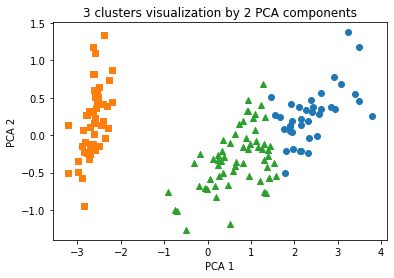

In [9]:
marker0_idx = iris_df[iris_df['cluster']==0].index
marker1_idx = iris_df[iris_df['cluster']==1].index
marker2_idx = iris_df[iris_df['cluster']==2].index

plt.scatter(x=iris_df.loc[marker0_idx, 'pca_x'], y=iris_df.loc[marker0_idx, 'pca_y'], marker='o')
plt.scatter(x=iris_df.loc[marker1_idx, 'pca_x'], y=iris_df.loc[marker1_idx, 'pca_y'], marker='s')
plt.scatter(x=iris_df.loc[marker2_idx, 'pca_x'], y=iris_df.loc[marker2_idx, 'pca_y'], marker='^')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('3 clusters visualization by 2 PCA components')
plt.show()

# 군집화 알고리즘 테스트를 위한 데이터 생성
* 사이킷런은 다양한 유형의 군집화 알고리즘을 테스트해보기 위한 간단한 데이터 생성기 제공
  * make_blobs(), make_classification() API 등 제공
  * 둘 다 여러 개의 클래스에 해당하는 데이터 세트를 만듦. 하나의 클래스에 여러 개의 군집이 분포될 수 있게 데이터 생성하 ㄹ수 있음
  * make_blobs() : 개별 군집의 중심점과 표준 편차 제어 기능 추가되어 있음
  * make_classification() : 노이즈를 포함한 데이터를 만드는 데 우용
  * 둘 다 분류 용도로도 테스트 데이터 생성 가능
  * make_circle(), make_moon() API : 중심 기반의 군집화로 해결 어려운 데이터셋 만드는 데 사용
* make_blobs()
  * 반환 : 피처 데이터셋과 타깃 데이터셋이 튜플로 반환됨
  * 호출 파라미터
    * n_samples : 생성할 총 데이터 개수. 디폴트=100
    * n_features : 데이터 피처 개수. 시각화하려면 2개로(x, y 각각)
    * centers : 정수형이면 군집의 개수 / 넘파이 어레이는 개별 군집 중심점의 좌표
    * cluster_std : 생성될 준집 데이터의 표준편차. 배열로 선언하면 군집별로 서로 다른 표준편차 가진 데이터셋 만들 때 사용. 작을 수록 군집 주임에 데이터가 모여있고, 클수록 데이터가 퍼져 있음

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
%matplotlib inline

x, y = make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=0.8, random_state=0)
print(x.shape, y.shape)
unique, counts = np.unique(y, return_counts=True) #y target 값의 분포 확인
print(unique, counts)

(200, 2) (200,)
[0 1 2] [67 67 66]


In [11]:
# 데이터 가공 쉽게 dt로 변환

import pandas as pd

cluster_df = pd.DataFrame(data=x, columns=['ftr1', 'ftr2'])
cluster_df['target']=y
cluster_df.head(3)

,ftr1,ftr2,target
0,-1.692427,3.622025,2
1,0.697940,4.428867,0
2,1.100228,4.606317,0


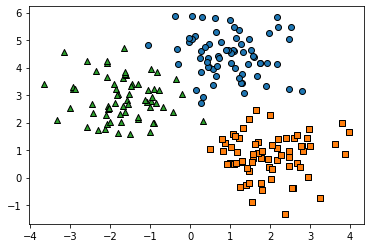

In [13]:
# make_blob()으로 만든 피처 데이터셋이 어떠한 군집화 분포 가지고 만들어졌는지 확인하기

target_list = np.unique(y)
markers = ['o', 's', '^', 'P', 'D', 'H', 'x']
for target in target_list:
    target_cluster = cluster_df[cluster_df['target']==target]
    plt.scatter(x=target_cluster['ftr1'], y=target_cluster['ftr2'], edgecolor='k', marker=markers[target])
plt.show()

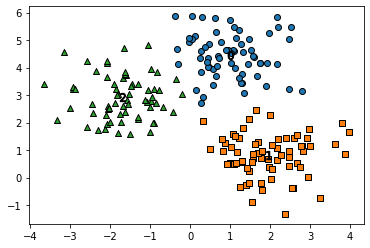

In [17]:
# 이렇게 만들어진 데이터셋에 KMeans 군집화를 수행, 군집별로 시각화

kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=200, random_state=0)
cluster_labels = kmeans.fit_predict(x)
cluster_df['kmeans_label'] = cluster_labels

centers = kmeans.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers = ['o', 's', '^', 'P', 'D', 'H', 'x']

for label in unique_labels:
    label_cluster = cluster_df[cluster_df['kmeans_label']==label]
    center_xy = centers[label]
    plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k', marker=markers[label])
    plt.scatter(x=center_xy[0], y=center_xy[1], s=70, color='k', edgecolor='k', marker='$%d$' % label)
plt.show()

# make_blobs()의 타깃과 kmeans_label은 군집 번호를 의미하므로 서로 다른 값으로 매핑될 수 있음

In [18]:
print(cluster_df.groupby('target')['kmeans_label'].value_counts())

target  kmeans_label
0       0               66
        2                1
1       1               67
2       2               65
        1                1
Name: kmeans_label, dtype: int64
